In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, kruskal

# Load each data

In [11]:
benin = pd.read_csv('../data/benin_clean.csv')
sierra_leone = pd.read_csv('../data/sierraleone_clean.csv')
togo = pd.read_csv('../data/togo_clean.csv')


# Metric Comparison

    Box Plot

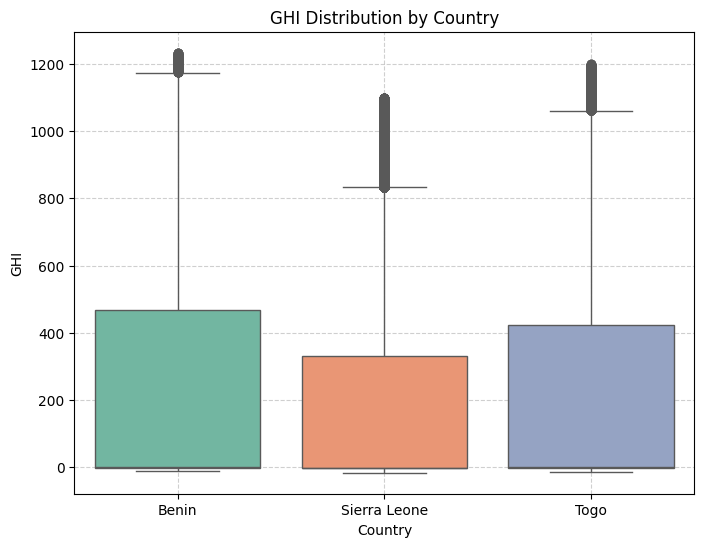

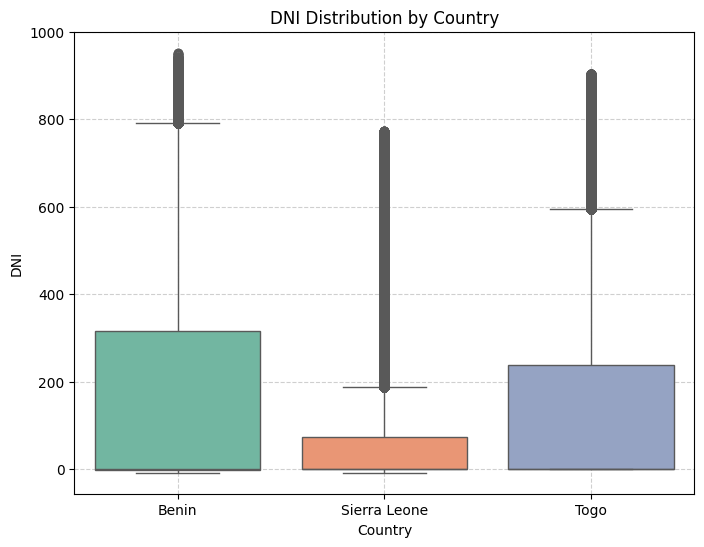

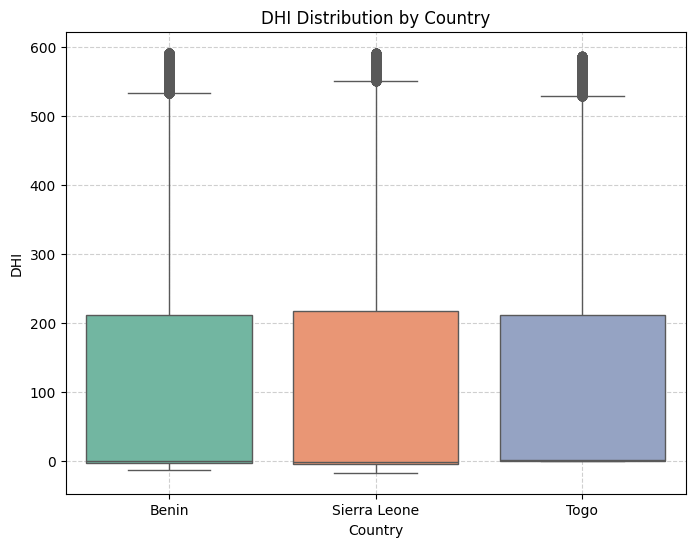

In [12]:
#combine data
combined = pd.concat([
    benin.assign(Country='Benin'),
    sierra_leone.assign(Country='Sierra Leone'),
    togo.assign(Country='Togo')
])

metrics = ["GHI", "DNI", "DHI"]

for metric in metrics:
    plt.figure(figsize=(8,6))
    sns.boxplot(x="Country", y=metric, data= combined, palette="Set2", hue="Country", legend=False)
    plt.title(f"{metric} Distribution by Country")
    plt.xlabel("Country")
    plt.ylabel(metric)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Summary Table

In [13]:
# calculate stats
stats = combined.groupby('Country')[metrics].agg(['mean', 'median', 'std']).round(2)
print(stats)

                 GHI                    DNI                    DHI         \
                mean median     std    mean median     std    mean median   
Country                                                                     
Benin         236.23    0.7  328.29  166.90   -0.1  262.08  111.66    0.5   
Sierra Leone  185.00   -0.4  279.02  104.13   -0.1  200.95  108.10   -0.6   
Togo          223.86    0.5  317.31  147.98    0.0  247.68  112.78    1.5   

                      
                 std  
Country               
Benin         153.10  
Sierra Leone  153.69  
Togo          151.57  


# Statistical Testing

In [14]:
# Define a function to run tests
def test_significance(metric):
    # Extract data per country
    benin = combined.loc[combined['Country']=='Benin'][metric]
    sierra = combined.loc[combined['Country']=='Sierra Leone'][metric]
    togo = combined.loc[combined['Country']=='Togo'][metric]
    
    # ANOVA (assumes normality)
    anova_result = f_oneway(benin, sierra, togo)
    # Kruskal-Wallis (non-parametric)
    kruskal_result = kruskal(benin, sierra, togo)
    
    print(f"--- {metric} ---")
    print(f"ANOVA p-value: {anova_result.pvalue:.4f}")
    print(f"Kruskal-Wallis p-value: {kruskal_result.pvalue:.4f}\n")

# Run tests for GHI, DNI, DHI
test_significance('GHI')
test_significance('DNI')
test_significance('DHI')

--- GHI ---
ANOVA p-value: 0.0000
Kruskal-Wallis p-value: 0.0000

--- DNI ---
ANOVA p-value: 0.0000
Kruskal-Wallis p-value: 0.0000

--- DNI ---
ANOVA p-value: 0.0000
Kruskal-Wallis p-value: 0.0000

--- DHI ---
ANOVA p-value: 0.0000
Kruskal-Wallis p-value: 0.0000

--- DHI ---
ANOVA p-value: 0.0000
Kruskal-Wallis p-value: 0.0000



# Visual Summary

In [ ]:
# Create a 1x3 grid for GHI, DNI, DHI
cleaned = combined[(combined[['GHI', 'DNI', 'DHI']] >= 0).all(axis=1)]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# GHI Ranking
sns.barplot(x='Country', y='GHI', hue='Country', data=cleaned, 
            estimator='mean', order=['Sierra Leone', 'Benin', 'Togo'],
            palette='Oranges_d', ax=axes[0], legend=False)
axes[0].set_title('Average GHI Ranking')
axes[0].set_ylabel('GHI (W/m²)')
axes[0].set_xlabel('')

# DNI Ranking
sns.barplot(x='Country', y='DNI', hue='Country', data=cleaned,
            estimator='mean', order=['Sierra Leone', 'Benin', 'Togo'],
            palette='Blues_d', ax=axes[1], legend=False)
axes[1].set_title('Average DNI Ranking')
axes[1].set_ylabel('DNI (W/m²)')
axes[1].set_xlabel('')

# DHI Ranking
sns.barplot(x='Country', y='DHI', hue='Country', data=cleaned,
            estimator='mean', order=['Togo', 'Benin', 'Sierra Leone'],
            palette='Greens_d', ax=axes[2], legend=False)
axes[2].set_title('Average DHI Ranking')
axes[2].set_ylabel('DHI (W/m²)')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

# Key Observations

- Inclusion of all three countries in plots
    - All visualizations use the combined dataframe with Country labels, so each plot includes Benin, Sierra Leone and Togo. Boxplots and the 1×3 barplot grid show per-country distributions and mean comparisons side-by-side, enabling direct visual comparison.

- Correct implementation and reporting of p-values
    - Statistical tests: one-way ANOVA (f_oneway) and Kruskal–Wallis are computed per metric (GHI, DNI, DHI), which is appropriate: ANOVA for mean differences under normality/homoscedasticity, Kruskal–Wallis as a nonparametric check.
    - Recommendation for reporting: report the test statistic and exact p-value (e.g., p = 0.002) for both tests, state the alpha (e.g., 0.05), and indicate which test result you rely on depending on assumptions. If a global test is significant, follow up with pairwise post-hoc tests (Tukey HSD for ANOVA or Dunn test with p‑value correction for Kruskal) and report adjusted p-values and effect sizes.

- Summary table (mean / median / SD) and numeric observations
    - A summary table comparing mean / median / SD per metric and country is already produced (stats). Key numeric observations from that table:
        - GHI (mean): Benin ≈ 236.2, Togo ≈ 223.9, Sierra Leone ≈ 185.0 → Benin highest mean GHI, Sierra Leone lowest.
        - DNI (mean): Benin ≈ 166.9, Togo ≈ 148.0, Sierra Leone ≈ 104.1 → similar ordering; Benin much higher DNI than Sierra Leone.
        - DHI (mean): Benin ≈ 111.7, Togo ≈ 112.8, Sierra Leone ≈ 108.1 → DHI means are close across countries (little practical difference).
        - Medians for irradiance metrics are near zero or negative in the raw table because night-time values are included; medians during daylight will be much more informative.

- Relevance and actionability of the insights
    - For solar resource selection: Benin shows the highest mean direct and global irradiance — attractive for PV or concentrating systems that benefit from high DNI. Togo is close behind for GHI and DHI. Sierra Leone has consistently lower DNI and GHI and may be less favorable for high-direct systems.
    - Because DHI is similar across countries, diffuse component alone does not differentiate sites strongly — system choice should weigh DNI and GHI differences.
    - High standard deviations indicate substantial variability; assess intra-day and seasonal patterns before committing to system sizing.

- Practical next steps (actionable)
    - Remove night-time data (filter GHI>0) and recompute summary stats and medians to get representative daylight values.
    - Check ANOVA assumptions: visualize residuals, run Levene’s test for equal variances; if violated, prefer Kruskal–Wallis and Dunn post-hoc with multiple‑test correction.
    - Run pairwise post-hoc tests and report adjusted p-values and effect sizes to identify which country pairs differ significantly.
    - Add confidence intervals / error bars to mean-comparison plots, and consider plotting seasonal/monthly means to capture temporal availability.
    - If planning deployment, combine mean/variability with operational constraints (grid access, land, cost) before prioritizing sites.

Concise conclusion: Benin has the highest mean GHI and DNI and is the strongest candidate from raw irradiance means; Togo is similar for GHI/DHI; Sierra Leone has lower mean GHI/DNI. Validate these findings using daylight‑only data, post‑hoc testing (with corrected p‑values), and temporal analyses before making final decisions.